## Parte 3: Benchmarking de Técnicas de Machine Learning

1. Selección de Modelos:
*   Entrenar y evaluar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).
*   Utilizar validación cruzada para evaluar el rendimiento de los modelos.
2. Comparación de Modelos:
*   Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
*   Seleccionar el mejor modelo basado en las métricas obtenidas.



In [34]:
#Repetimos los pasos de preprocesamiento
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import contextlib


#Silenciar warnings
warnings.filterwarnings('ignore')

#Silenciar stdout y stderr
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as fnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = fnull
        sys.stderr = fnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

#Cargamos el dataset

df = pd.read_csv('../data/retail_sales_dataset.csv')

#Separamos las variables predictoras y la variable objetivo
X = df.drop(columns=['Gender'])
y = df['Gender']

#Separamos el dataset en conjunto de entrenamiento y conjunto de prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Convertimos la columna 'Date' a tipo datetime y extraemos el mes

for dataset in [X_train, X_test]:
    dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')
    dataset['Mes'] = dataset['Date'].dt.month
    dataset.drop(columns=['Date'], inplace=True)

categorical_features=['Product Category']
numerical_features=['Age', 'Mes', 'Quantity', 'Price per Unit']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value='other')), #creamos la categoría "other", para los datos faltantes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer_nan', KNNImputer(n_neighbors=5)), #imputamos con KNN los datos a los faltantes
    ('scaler',StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer, categorical_features),
        ('numerical', numerical_transformer, numerical_features)
        ])

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

Definiremos un diccionario con las consiguraciones de los modelos, para luego hacer su entrenamiento y optimización, con GridSearchCV

In [35]:
model_configs = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.01, 0.1, 1],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear', 'saga']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [None, 10]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [None, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.01, 0.1]
        }
    },
    'LGBM': {
        'model': LGBMClassifier(random_state=42,verbosity=-1),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [-1, 5],
            'classifier__learning_rate': [0.01, 0.1]
        }
    }
}

Vamos a realizar el entrenamiento, evaluación y búsqueda de hiperparámetros. Los resultados del mejor modelo (y los datos que nos servirán para compararlos) se guardarán en la carpeta 'Reports'


=== LogisticRegression ===
Mejores Hiperparámetros: {'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
AUC: 0.5000
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       105
           1       0.00      0.00      0.00        95

    accuracy                           0.53       200
   macro avg       0.26      0.50      0.34       200
weighted avg       0.28      0.53      0.36       200

Matriz de Confusión:
[[105   0]
 [ 95   0]]

=== KNN ===
Mejores Hiperparámetros: {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
AUC: 0.4621
              precision    recall  f1-score   support

           0       0.53      0.48      0.50       105
           1       0.48      0.54      0.51        95

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200

Matriz de Confusión:
[[50 55]
 [4

/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.w

Mejores Hiperparámetros: {'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__n_estimators': 100}
AUC: 0.4581
              precision    recall  f1-score   support

           0       0.52      0.53      0.53       105
           1       0.47      0.46      0.47        95

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

Matriz de Confusión:
[[56 49]
 [51 44]]


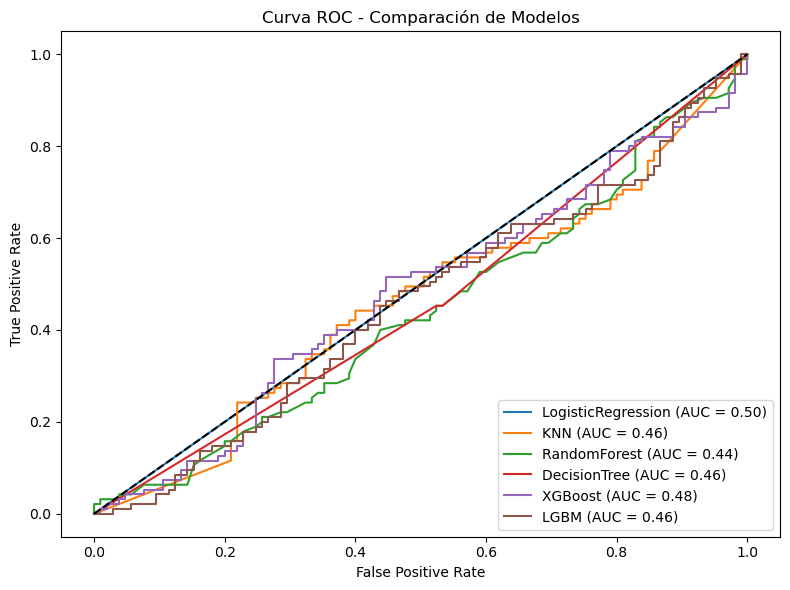

/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pedro/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.w

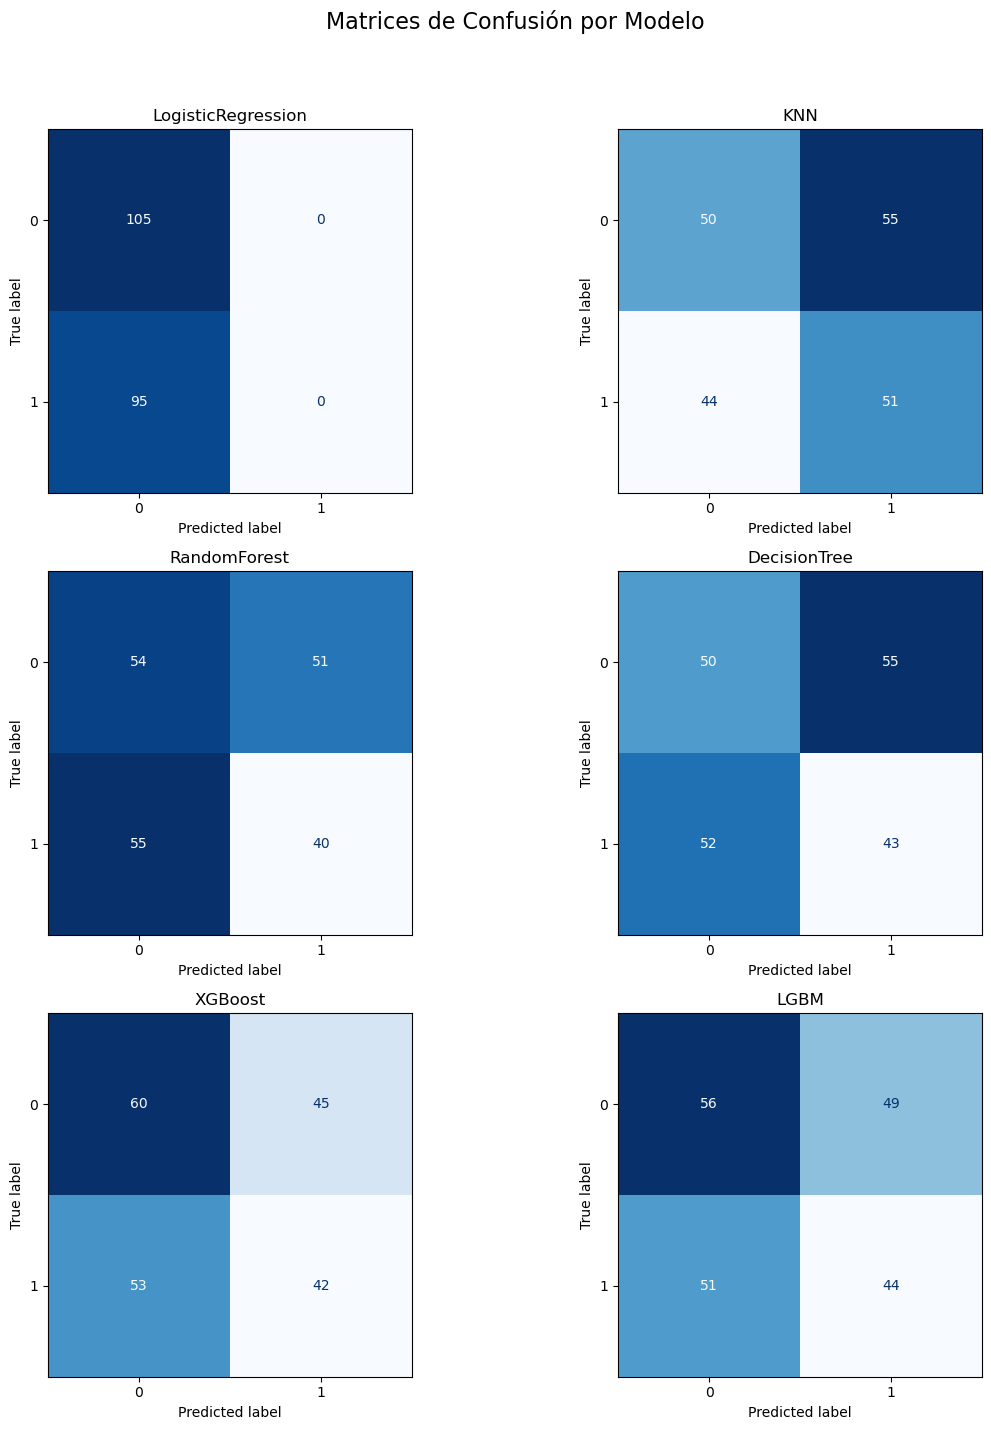

In [36]:
REPORTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports'))
os.makedirs(REPORTS_DIR, exist_ok=True)

# Inicializar variables para almacenar resultados
results = []
roc_data = {}
best_model_name = None
best_auc = 0
best_preds = None
best_y_test = None

with open(os.path.join(REPORTS_DIR, 'classification_report.txt'), 'w') as report_file:
    for name, cfg in model_configs.items():
        print(f"\n=== {name} ===")
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', cfg['model'])
        ])
        grid = GridSearchCV(pipe, cfg['params'], cv=5, scoring='roc_auc', n_jobs=-1)

        with suppress_stdout_stderr():
            grid.fit(X_train, y_train_enc)

        y_pred = grid.predict(X_test)
        y_proba = grid.predict_proba(X_test)[:, 1]

        # Métricas
        report = classification_report(y_test_enc, y_pred, zero_division=0)
        fpr, tpr, _ = roc_curve(y_test_enc, y_proba)
        roc_auc = auc(fpr, tpr)

        # Mostrar en consola
        print(f"Mejores Hiperparámetros: {grid.best_params_}")
        print(f"AUC: {roc_auc:.4f}")
        print(report)
        print("Matriz de Confusión:")
        print(confusion_matrix(y_test_enc, y_pred))

        # Guardar en archivo
        report_file.write(f"=== {name} ===\n")
        report_file.write(f"Best Params: {grid.best_params_}\n")
        report_file.write(f"AUC: {roc_auc:.4f}\n")
        report_file.write(report + "\n")
        report_file.write(str(confusion_matrix(y_test_enc, y_pred)) + "\n\n")

        # Guardar datos para curva ROC
        roc_data[name] = (fpr, tpr, roc_auc)

# === CURVA ROC DE TODOS LOS MODELOS ===
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'roc_curve.png'))
plt.show()
plt.close()

n_models = len(roc_data)
cols = 2
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axes = axes.flatten()

for idx, (name, cfg) in enumerate(model_configs.items()):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', cfg['model'])
    ])
    grid = GridSearchCV(pipe, cfg['params'], cv=5, scoring='roc_auc', n_jobs=-1)

    with suppress_stdout_stderr():
        grid.fit(X_train, y_train_enc)

    y_pred = grid.predict(X_test)

    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name)

# Quitar subplots vacíos si hay un número impar de modelos
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Matrices de Confusión por Modelo', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(REPORTS_DIR, 'confusion_matrices.png'))
plt.show()
plt.close()


## Conclusiones

Como habíamos previsto, los modelos tienen un muy mal desempeño, posiblemente debido a las escasas diferencias de comportamiento que vimos en la EDA.